# LDA Topic Modeling — Constitution Corpus
DS 5001 Text as Data

# Set Up

In [75]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.decomposition import LatentDirichletAllocation as LDA, NMF
from sklearn.feature_extraction import text # For stopwords

In [76]:
data_home  = 'parsed_data'        
output_dir = 'models'          # where to write outputs
data_prefix = 'const'
colors = 'YlGnBu'

# Load Existing Tables

In [77]:
CORPUS = pd.read_csv(f'{data_home}/const_TOKEN.csv')

VOCAB_FULL = pd.read_csv(f'{data_home}/const_VOCAB.csv', index_col='term_str')

print('CORPUS shape:', CORPUS.shape)
print('VOCAB  shape:', VOCAB_FULL.shape)

CORPUS shape: (4263565, 11)
VOCAB  shape: (39730, 17)


# Build Document Strings

LDA via sklearn expects one string per document. Here each constitution (country) is a document.

We filter to **nouns and verbs only** (POS groups `NOUN` and `VERB`) and remove stopwords, then join the remaining tokens back into a single string per country.

In [78]:
content_pos = ['NOUN', 'VERB']

my_stop_words = ['shall', 'may', 'law', 'state', 'article', 'section', 'provision']
stop_words = list(text.ENGLISH_STOP_WORDS.union(my_stop_words))

filtered = CORPUS[
    (CORPUS['pos_group'].isin(content_pos)) &
    (~CORPUS['term_str'].isin(stop_words))
].copy()

filtered = filtered.dropna(subset=['term_str'])

DOCS = (
    filtered
    .groupby('country_id')['term_str']
    .apply(lambda x: ' '.join(x))
    .to_frame('doc_content')
)
DOCS.index.name = 'country_id'

print(f'{len(DOCS)} documents')
DOCS.head()

192 documents


,doc_content
country_id,
Afghanistan_2004,share allah beneficent praise allah cherisher ...
Albania_2008,albania rev share people albania proud aware h...
Algeria_2008,algeria rev share people people decided remain...
Andorra_1993,andorra share andorran people liberty independ...
Angola_2010,angola share people angola representatives leg...


In [79]:
table_dir = 'derived_tables'

In [80]:
DTM = pd.read_parquet(f'{table_dir}/const_DTM.parquet')

In [81]:
TERMS = DTM.columns.values

In [82]:
TFIDF = pd.read_parquet(f'{table_dir}/const_TFIDF_L2.parquet')

# Fit LDA Model — THETA and PHI

In [83]:
n_topics = 40
model_args = dict(
    n_components    = n_topics,
    max_iter        = 50,
    learning_method = 'batch',
    random_state    = 42,
)
n_top_terms = 7
zfill_padding = len(str(n_topics))
TNAMES = [f"T{str(x).zfill(zfill_padding)}" for x in range(n_topics)]

In [84]:
from sklearn.feature_extraction.text import CountVectorizer

my_stop_words = ['shall', 'may', 'law', 'state', 'article', 'section', 'provision']
stop_words = list(text.ENGLISH_STOP_WORDS.union(my_stop_words))

vectorizer = CountVectorizer(stop_words=stop_words)
X_filtered = vectorizer.fit_transform(DOCS['doc_content'])
TERMS = vectorizer.get_feature_names_out()

topic_engine = LDA(**model_args)
topic_model = topic_engine.fit_transform(X_filtered)

THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'

PHI = pd.DataFrame(
    topic_engine.components_ / topic_engine.components_.sum(axis=1, keepdims=True),
    columns=TERMS,
    index=TNAMES
)
PHI.index.name   = 'topic_id'
PHI.columns.name = 'term_str'

In [85]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS.head()

,top_terms
topic_id,
T00,court office person constitution provisions fe...
T01,people share national organs committee congres...
T02,druk gyalpo bhutan parliament national members...
T03,share parliament national constitution act leg...
T04,share ii rights assembly development legislati...


In [86]:
topic_meta = {
    'T00': {'gloss': 'Preamble & Foundational Language', 'subgroup': 'Founding Text', 'group': 'Foundations'},
    'T01': {'gloss': 'Sovereignty & State Authority', 'subgroup': 'State Structure', 'group': 'Foundations'},
    'T02': {'gloss': 'Human Rights & Civil Liberties', 'subgroup': 'Rights', 'group': 'Rights & Freedoms'},
    'T03': {'gloss': 'Political Rights & Electoral Participation', 'subgroup': 'Democratic Rights', 'group': 'Rights & Freedoms'},
    'T04': {'gloss': 'Freedom of Speech & Press', 'subgroup': 'Civil Liberties', 'group': 'Rights & Freedoms'},
    'T05': {'gloss': 'Freedom of Religion & Belief', 'subgroup': 'Civil Liberties', 'group': 'Rights & Freedoms'},
    'T06': {'gloss': 'Equality & Anti-Discrimination', 'subgroup': 'Rights', 'group': 'Rights & Freedoms'},

    'T07': {'gloss': 'Executive Power Structure', 'subgroup': 'Government Branches', 'group': 'Institutions'},
    'T08': {'gloss': 'Legislature & Parliamentary Systems', 'subgroup': 'Government Branches', 'group': 'Institutions'},
    'T09': {'gloss': 'Judiciary & Constitutional Courts', 'subgroup': 'Government Branches', 'group': 'Institutions'},
    'T10': {'gloss': 'Separation of Powers & Checks and Balances', 'subgroup': 'Institutional Design', 'group': 'Institutions'},

    'T11': {'gloss': 'Elections & Voting Systems', 'subgroup': 'Democratic Institutions', 'group': 'Electoral Systems'},
    'T12': {'gloss': 'Political Parties & Representation', 'subgroup': 'Democratic Institutions', 'group': 'Electoral Systems'},
    'T13': {'gloss': 'Electoral Integrity & Fairness', 'subgroup': 'Democratic Quality', 'group': 'Electoral Systems'},

    'T14': {'gloss': 'Federalism & Regional Autonomy', 'subgroup': 'Territorial Structure', 'group': 'State Structure'},
    'T15': {'gloss': 'Local Government & Decentralization', 'subgroup': 'Territorial Structure', 'group': 'State Structure'},

    'T16': {'gloss': 'Emergency Powers & Authoritarian Exceptions', 'subgroup': 'Crisis Governance', 'group': 'Power Limits'},
    'T17': {'gloss': 'Military & Security Institutions', 'subgroup': 'State Power', 'group': 'Power Limits'},

    'T18': {'gloss': 'Amendment Procedures & Constitutional Change', 'subgroup': 'Legal Structure', 'group': 'Constitutional Stability'},

    'T19': {'gloss': 'Economic Rights & Property Protections', 'subgroup': 'Socioeconomic Rights', 'group': 'Rights & Freedoms'},
    'T20': {'gloss': 'Welfare State & Social Guarantees', 'subgroup': 'Socioeconomic Rights', 'group': 'Rights & Freedoms'},

    'T21': {'gloss': 'Rule of Law & Legal Equality', 'subgroup': 'Judicial Principles', 'group': 'Institutions'},
    'T22': {'gloss': 'Anti-Corruption & Accountability Mechanisms', 'subgroup': 'Governance Quality', 'group': 'Institutions'},

    'T23': {'gloss': 'Democratic Backsliding / Authoritarian Clauses', 'subgroup': 'Regime Control', 'group': 'Power Limits'},
}

tm = pd.DataFrame(topic_meta).T
tm.index.name = 'topic_id'
# An exception is thrown if we already made the join
try:
    TOPICS = TOPICS.join(tm)
except ValueError as e:
    print("Already joined.")
del(tm)
TOPICS['label'] = TOPICS.apply(lambda x: f"{x.name} {x.gloss}", axis=1)
TOPICS

,top_terms,gloss,subgroup,group,label
topic_id,,,,,
T00,court office person constitution provisions fe...,Preamble & Foundational Language,Founding Text,Foundations,T00 Preamble & Foundational Language
T01,people share national organs committee congres...,Sovereignty & State Authority,State Structure,Foundations,T01 Sovereignty & State Authority
T02,druk gyalpo bhutan parliament national members...,Human Rights & Civil Liberties,Rights,Rights & Freedoms,T02 Human Rights & Civil Liberties
T03,share parliament national constitution act leg...,Political Rights & Electoral Participation,Democratic Rights,Rights & Freedoms,T03 Political Rights & Electoral Participation
T04,share ii rights assembly development legislati...,Freedom of Speech & Press,Civil Liberties,Rights & Freedoms,T04 Freedom of Speech & Press
T05,parliament government president act share mini...,Freedom of Religion & Belief,Civil Liberties,Rights & Freedoms,T05 Freedom of Religion & Belief
T06,share rights national persons office constitut...,Equality & Anti-Discrimination,Rights,Rights & Freedoms,T06 Equality & Anti-Discrimination
T07,federation bodies share government powers laws...,Executive Power Structure,Government Branches,Institutions,T07 Executive Power Structure
T08,share president republic congress constitution...,Legislature & Parliamentary Systems,Government Branches,Institutions,T08 Legislature & Parliamentary Systems


In [87]:
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()

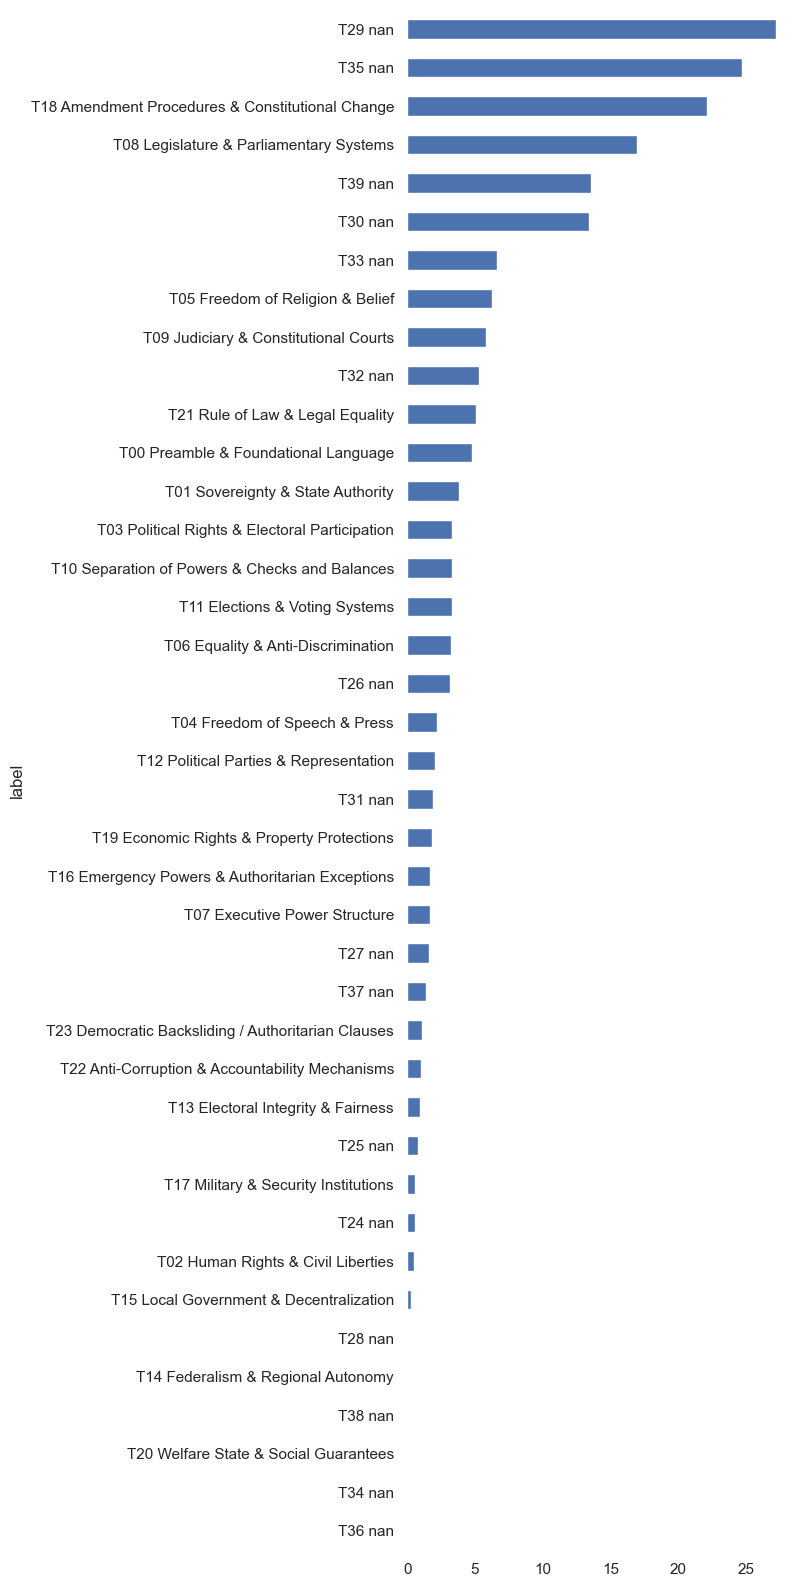

In [88]:
TOPICS.sort_values('doc_weight_sum', 
    ascending=True).plot.barh(y='doc_weight_sum', x='label', 
    figsize=(5, n_topics/2), legend=False)
sns.despine(left=True, bottom=True)
plt.show()

In [89]:
TOPICS.group.value_counts()

group
Rights & Freedoms           7
Institutions                6
Electoral Systems           3
Power Limits                3
Foundations                 2
State Structure             2
Constitutional Stability    1
Name: count, dtype: int64

In [90]:
top5 = (
    THETA.mean()
    .sort_values(ascending=False)
    .head(5)
)

for topic_id in top5.index:
    top_words = (
        PHI.loc[topic_id]
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )
    
    print(f"{topic_id}:")
    print("Top 5 words:", ", ".join(top_words))
    print("Mean document weight:", round(top5[topic_id], 4))
    print()

T29:
Top 5 words: share, president, republic, national, council
Mean document weight: 0.1418

T35:
Top 5 words: person, office, court, constitution, member
Mean document weight: 0.1287

T18:
Top 5 words: share, president, republic, assembly, constitution
Mean document weight: 0.1151

T08:
Top 5 words: share, president, republic, congress, constitution
Mean document weight: 0.0882

T39:
Top 5 words: republic, share, right, president, constitution
Mean document weight: 0.0707



In [92]:
DOCS.to_csv(f"{output_dir}/{data_prefix}-DOCS.csv", index=True)
THETA.to_csv(f"{output_dir}/{data_prefix}-THETA.csv", index=True)
PHI.to_csv(f"{output_dir}/{data_prefix}-PHI.csv", index=True)
TOPICS.to_csv(f"{output_dir}/{data_prefix}-TOPICS.csv", index=True)